In [40]:
import pandas as pd
import os

# Write the folder name only once
data_folder = "vol_1_rsi_1_bb_1_ma_1"

# Build paths from that
csv_path = os.path.join(data_folder, "labels.csv")

# Load csv
df = pd.read_csv(csv_path)

# Convert dates
df["start_date"] = pd.to_datetime(df["start_date"])
df["end_date"] = pd.to_datetime(df["end_date"])

# Use end_date as the observation date for splitting
df["date"] = df["end_date"]

print(df.head())
print(df.info())
print(df["label"].value_counts())

                                          image_path ticker start_date  \
0  vol_1_rsi_1_bb_1_ma_1\AAPL\AAPL_2020-01-30_to_...   AAPL 2020-01-30   
1  vol_1_rsi_1_bb_1_ma_1\AAPL\AAPL_2020-02-06_to_...   AAPL 2020-02-06   
2  vol_1_rsi_1_bb_1_ma_1\AAPL\AAPL_2020-02-13_to_...   AAPL 2020-02-13   
3  vol_1_rsi_1_bb_1_ma_1\AAPL\AAPL_2020-02-21_to_...   AAPL 2020-02-21   
4  vol_1_rsi_1_bb_1_ma_1\AAPL\AAPL_2020-02-28_to_...   AAPL 2020-02-28   

    end_date  close_now  close_future  label       date  
0 2020-02-05     321.45        327.20      1 2020-02-05  
1 2020-02-12     327.20        320.30      0 2020-02-12  
2 2020-02-20     320.30        273.52      0 2020-02-20  
3 2020-02-27     273.52        292.92      1 2020-02-27  
4 2020-03-05     292.92        248.23      0 2020-03-05  
<class 'pandas.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   image_pat

Tjekker at Billederne eksistere og fjerner rækker hvor billeder ikke eksisterer

In [41]:
import os

df["file_exists"] = df["image_path"].apply(os.path.exists)

print(df["file_exists"].value_counts())

# Keep only rows where the image exists
df = df[df["file_exists"]].copy()

file_exists
True    735
Name: count, dtype: int64


Sorterer data efter tid, så rækker der tilhører samme Ticker/firma ikke længere kommer efter hinanden. Det er fordi man i Finans verden gerne vil bruge gammel data til at forudsige ny data. Altså skal rækker med samme Ticker/firma ikke ligge sammen. Derimod skal den træne gammel data fra alle de forskellige Firmaer.

In [42]:
df = df.sort_values("date").reset_index(drop=True)
print(len(df))

735


Step 5: Split by unique dates, not by rows

This is important. Since many companies share the same dates, it is better to split by the set of unique dates.

In [43]:
unique_dates = sorted(df["date"].unique())

n_dates = len(unique_dates)
train_end = int(n_dates * 0.70)
val_end = int(n_dates * 0.85)

train_dates = unique_dates[:train_end]
val_dates = unique_dates[train_end:val_end]
test_dates = unique_dates[val_end:]

train_df = df[df["date"].isin(train_dates)].copy()
val_df   = df[df["date"].isin(val_dates)].copy()
test_df  = df[df["date"].isin(test_dates)].copy()

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

Train shape: (513, 9)
Val shape: (111, 9)
Test shape: (111, 9)


In [44]:
print("\nDate ranges:")
print("Train:", train_df["date"].min(), "to", train_df["date"].max())
print("Val:  ", val_df["date"].min(), "to", val_df["date"].max())
print("Test: ", test_df["date"].min(), "to", test_df["date"].max())

print("\nNumber of tickers:")
print("Train:", train_df["ticker"].nunique())
print("Val:  ", val_df["ticker"].nunique())
print("Test: ", test_df["ticker"].nunique())

print("\nLabel balance:")
print("Train:\n", train_df["label"].value_counts(normalize=True))
print("Val:\n", val_df["label"].value_counts(normalize=True))
print("Test:\n", test_df["label"].value_counts(normalize=True))


Date ranges:
Train: 2020-02-05 00:00:00 to 2023-06-22 00:00:00
Val:   2023-06-29 00:00:00 to 2024-03-18 00:00:00
Test:  2024-03-25 00:00:00 to 2024-12-10 00:00:00

Number of tickers:
Train: 3
Val:   3
Test:  3

Label balance:
Train:
 label
1    0.551657
0    0.448343
Name: proportion, dtype: float64
Val:
 label
1    0.558559
0    0.441441
Name: proportion, dtype: float64
Test:
 label
1    0.558559
0    0.441441
Name: proportion, dtype: float64


In [45]:
train_df.to_csv("train_split.csv", index=False)
val_df.to_csv("val_split.csv", index=False)
test_df.to_csv("test_split.csv", index=False)

In [46]:
import sys
print(sys.executable)

c:\Users\morte\AppData\Local\Programs\Python\Python314\python.exe


Image batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
First 10 labels: tensor([0, 0, 1, 0, 1, 0, 0, 1, 1, 1])


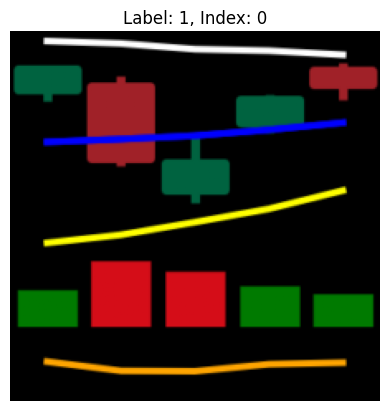

In [47]:
import pandas as pd
from PIL import Image
import torch
import torchvision
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt

class StockImageDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        return image, label, idx

basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = StockImageDataset(train_df, transform=basic_transform)
val_dataset   = StockImageDataset(val_df, transform=basic_transform)
test_dataset  = StockImageDataset(test_df, transform=basic_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Test one batch
images, labels, idx = next(iter(train_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("First 10 labels:", labels[:10])

# Show one example image
image, label, idx = train_dataset[0]
img_np = image.permute(1, 2, 0).numpy()

plt.imshow(img_np)
plt.title(f"Label: {label}, Index: {idx}")
plt.axis("off")
plt.show()

Hvis PyTorch bruger CPU i stedet for Nvidia GPU er det fordi du har installeret en CPU version af PyTorch. Så kan man køre følgende kommandoer for at få CUDA version med PyTorch
python -m pip uninstall -y torch torchvision torchaudio
python -m pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

In [48]:
import torch
import sys

print("Python:", sys.executable)
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Torch CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))

Python: c:\Users\morte\AppData\Local\Programs\Python\Python314\python.exe
Torch version: 2.10.0+cu126
CUDA available: True
Torch CUDA version: 12.6
GPU count: 1
GPU name: NVIDIA GeForce RTX 4070


In [49]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 224 -> 112

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 112 -> 56

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)    # 56 -> 28
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels, _ in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels, _ in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
best_val_loss = float("inf")

model_save_path = os.path.join(data_folder, "best_cnn.pth")


for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"  Train loss: {train_loss:.4f} | Train acc: {train_acc:.4f}")
    print(f"  Val   loss: {val_loss:.4f} | Val   acc: {val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), model_save_path)
        print("  Saved best model.")

Using device: cuda
Epoch 1/10
  Train loss: 0.7213 | Train acc: 0.5380
  Val   loss: 0.6871 | Val   acc: 0.5586
  Saved best model.
Epoch 2/10
  Train loss: 0.6897 | Train acc: 0.5517
  Val   loss: 0.6882 | Val   acc: 0.5586
Epoch 3/10
  Train loss: 0.6831 | Train acc: 0.5478
  Val   loss: 0.6917 | Val   acc: 0.5586
Epoch 4/10
  Train loss: 0.6854 | Train acc: 0.5536
  Val   loss: 0.6871 | Val   acc: 0.5405
Epoch 5/10
  Train loss: 0.6744 | Train acc: 0.5906
  Val   loss: 0.6956 | Val   acc: 0.5135
Epoch 6/10
  Train loss: 0.6786 | Train acc: 0.5478
  Val   loss: 0.6898 | Val   acc: 0.5766
Epoch 7/10
  Train loss: 0.6714 | Train acc: 0.5692
  Val   loss: 0.6934 | Val   acc: 0.5946
Epoch 8/10
  Train loss: 0.6600 | Train acc: 0.6004
  Val   loss: 0.7021 | Val   acc: 0.5766
Epoch 9/10
  Train loss: 0.6577 | Train acc: 0.5887
  Val   loss: 0.6986 | Val   acc: 0.5315
Epoch 10/10
  Train loss: 0.6648 | Train acc: 0.6043
  Val   loss: 0.6997 | Val   acc: 0.5315


In [50]:
import torch
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SimpleCNN().to(device)
model_save_path = os.path.join(data_folder, "best_cnn.pth")

model.load_state_dict(torch.load(model_save_path, map_location=device))

test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print(f"Test loss: {test_loss:.4f}")
print(f"Test acc:  {test_acc:.4f}")

Test loss: 0.6863
Test acc:  0.5586


In [51]:
import os
import torch
import torch.nn.functional as F

# Load best model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)

model_save_path = os.path.join(data_folder, "best_cnn.pth")
model.load_state_dict(torch.load(model_save_path, map_location=device))
model.eval()

# Reset index so dataset idx matches dataframe row
test_df = test_df.reset_index(drop=True)

# Create empty column for predicted probability of "up"
test_df["pred_prob_up"] = None

with torch.no_grad():
    for images, labels, indices in test_loader:
        images = images.to(device)

        outputs = model(images)

        # Option A: convert 2 logits to probabilities
        probs_up = F.softmax(outputs, dim=1)[:, 1].cpu().numpy()

        for i, idx in enumerate(indices.numpy()):
            test_df.loc[idx, "pred_prob_up"] = float(probs_up[i])

# Optional: also create predicted class from 0.5 threshold
test_df["pred_label"] = (test_df["pred_prob_up"].astype(float) >= 0.5).astype(int)

# Save file
predictions_path = os.path.join(data_folder, "test_predictions.csv")
test_df.to_csv(predictions_path, index=False)

print("Saved predictions to:", predictions_path)
print(test_df.head())

Saved predictions to: vol_1_rsi_1_bb_1_ma_1\test_predictions.csv
                                          image_path ticker start_date  \
0  vol_1_rsi_1_bb_1_ma_1\ABT\ABT_2024-03-19_to_20...    ABT 2024-03-19   
1  vol_1_rsi_1_bb_1_ma_1\AAPL\AAPL_2024-03-19_to_...   AAPL 2024-03-19   
2  vol_1_rsi_1_bb_1_ma_1\ABBV\ABBV_2024-03-19_to_...   ABBV 2024-03-19   
3  vol_1_rsi_1_bb_1_ma_1\AAPL\AAPL_2024-03-26_to_...   AAPL 2024-03-26   
4  vol_1_rsi_1_bb_1_ma_1\ABBV\ABBV_2024-03-26_to_...   ABBV 2024-03-26   

    end_date  close_now  close_future  label       date  file_exists  \
0 2024-03-25     110.01        112.02      1 2024-03-25         True   
1 2024-03-25     170.85        168.84      0 2024-03-25         True   
2 2024-03-25     178.53        180.69      1 2024-03-25         True   
3 2024-04-02     168.84        169.67      1 2024-04-02         True   
4 2024-04-02     180.69        170.14      0 2024-04-02         True   

  pred_prob_up  pred_label  
0     0.557366           1  

$$r_{t,t+5}=\frac{close\_future - close\_now}{close\_now}$$

In [78]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

pred_path = os.path.join(data_folder, "test_predictions.csv")
df = pd.read_csv(pred_path)

df["rebalance_date"] = pd.to_datetime(df["end_date"])
df["future_return_5d"] = (df["close_future"] - df["close_now"]) / df["close_now"]

print(df[["ticker", "rebalance_date", "pred_prob_up", "future_return_5d"]].head())

  ticker rebalance_date  pred_prob_up  future_return_5d
0    ABT     2024-03-25      0.557366          0.018271
1   AAPL     2024-03-25      0.563368         -0.011765
2   ABBV     2024-03-25      0.565992          0.012099
3   AAPL     2024-04-02      0.561152          0.004916
4   ABBV     2024-04-02      0.564630         -0.058387


In [84]:
n_groups = 3   # use 10 in final analysis

In [85]:
def assign_groups(prob_series):
    if len(prob_series) < n_groups:
        return pd.Series([np.nan] * len(prob_series), index=prob_series.index)

    ranked = prob_series.rank(method="first")

    return pd.qcut(
        ranked,
        q=n_groups,
        labels=False
    ) + 1

df["group"] = (
    df.groupby("rebalance_date")["pred_prob_up"]
      .transform(assign_groups)
)

df = df.dropna(subset=["group"]).copy()
df["group"] = df["group"].astype(int)

print(df[["ticker", "rebalance_date", "pred_prob_up", "group", "future_return_5d"]].head())

  ticker rebalance_date  pred_prob_up  group  future_return_5d
0    ABT     2024-03-25      0.557366      1          0.018271
1   AAPL     2024-03-25      0.563368      2         -0.011765
2   ABBV     2024-03-25      0.565992      3          0.012099
3   AAPL     2024-04-02      0.561152      2          0.004916
4   ABBV     2024-04-02      0.564630      3         -0.058387


In [86]:
portfolio_returns = (
    df.groupby(["rebalance_date", "group"])["future_return_5d"]
      .mean()
      .reset_index()
)

print(portfolio_returns.head())

  rebalance_date  group  future_return_5d
0     2024-03-25      1          0.018271
1     2024-03-25      2         -0.011765
2     2024-03-25      3          0.012099
3     2024-04-02      1          0.003749
4     2024-04-02      2          0.004916


In [87]:
portfolio_wide = portfolio_returns.pivot(
    index="rebalance_date",
    columns="group",
    values="future_return_5d"
)

portfolio_wide.columns = [f"G{int(c)}" for c in portfolio_wide.columns]

low_col = "G1"
high_col = f"G{n_groups}"

portfolio_wide["H-L"] = portfolio_wide[high_col] - portfolio_wide[low_col]

print(portfolio_wide.head())

                      G1        G2        G3       H-L
rebalance_date                                        
2024-03-25      0.018271 -0.011765  0.012099 -0.006172
2024-04-02      0.003749  0.004916 -0.058387 -0.062137
2024-04-09     -0.044669 -0.001709 -0.028726  0.015943
2024-04-16     -0.014834  0.043066 -0.014642  0.000192
2024-04-23     -0.015057 -0.040698  0.020551  0.035608


In [88]:
periods_per_year = 252 / 5

def annualized_return(r):
    return r.mean() * periods_per_year

def annualized_sharpe(r):
    std = r.std()
    if std == 0 or pd.isna(std):
        return np.nan
    return (r.mean() / std) * np.sqrt(periods_per_year)

def p_value_mean_zero(r):
    r = r.dropna()
    if len(r) < 2:
        return np.nan
    t_stat, p_val = stats.ttest_1samp(r, popmean=0.0, nan_policy="omit")
    return p_val

def stars_from_p(p):
    if pd.isna(p):
        return ""
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return ""

summary_rows = []

for g in range(1, n_groups + 1):
    col = f"G{g}"
    r = portfolio_wide[col].dropna()

    if g == 1:
        label = "Low"
    elif g == n_groups:
        label = "High"
    else:
        label = str(g)

    p = p_value_mean_zero(r)

    summary_rows.append({
        "Group": label,
        "Ret": annualized_return(r),
        "SR": annualized_sharpe(r),
        "p_value": p,
        "stars": stars_from_p(p)
    })

# Add H-L
r_hl = portfolio_wide["H-L"].dropna()
p_hl = p_value_mean_zero(r_hl)

summary_rows.append({
    "Group": "H-L",
    "Ret": annualized_return(r_hl),
    "SR": annualized_sharpe(r_hl),
    "p_value": p_hl,
    "stars": stars_from_p(p_hl)
})

summary_table = pd.DataFrame(summary_rows)

summary_table["Ret"] = summary_table["Ret"].round(2)
summary_table["SR_display"] = summary_table["SR"].map(lambda x: f"{x:.2f}") + summary_table["stars"]

print(summary_table[["Group", "Ret", "SR_display", "p_value"]].to_string(index=False))

Group   Ret SR_display  p_value
  Low  0.38       1.59 0.180825
    2  0.30       1.17 0.322209
 High -0.05      -0.28 0.809981
  H-L -0.43      -1.47 0.217112


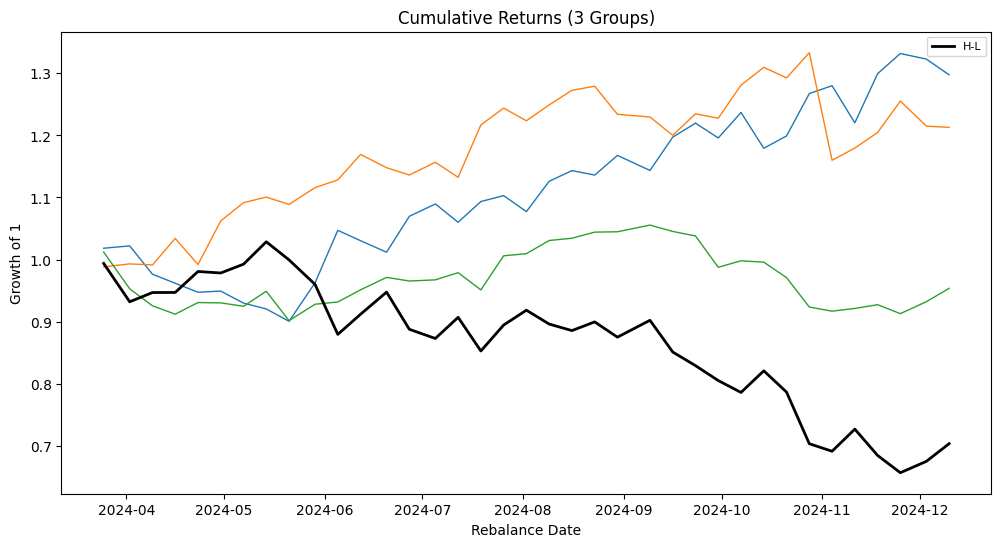

In [89]:
cum_df = (1 + portfolio_wide.fillna(0)).cumprod()

plt.figure(figsize=(12, 6))

for g in range(1, n_groups + 1):
    plt.plot(cum_df.index, cum_df[f"G{g}"], linewidth=1)

plt.plot(cum_df.index, cum_df["H-L"], linewidth=2, color="black", label="H-L")

plt.title(f"Cumulative Returns ({n_groups} Groups)")
plt.ylabel("Growth of 1")
plt.xlabel("Rebalance Date")
plt.legend(ncol=3, fontsize=8)
plt.show()

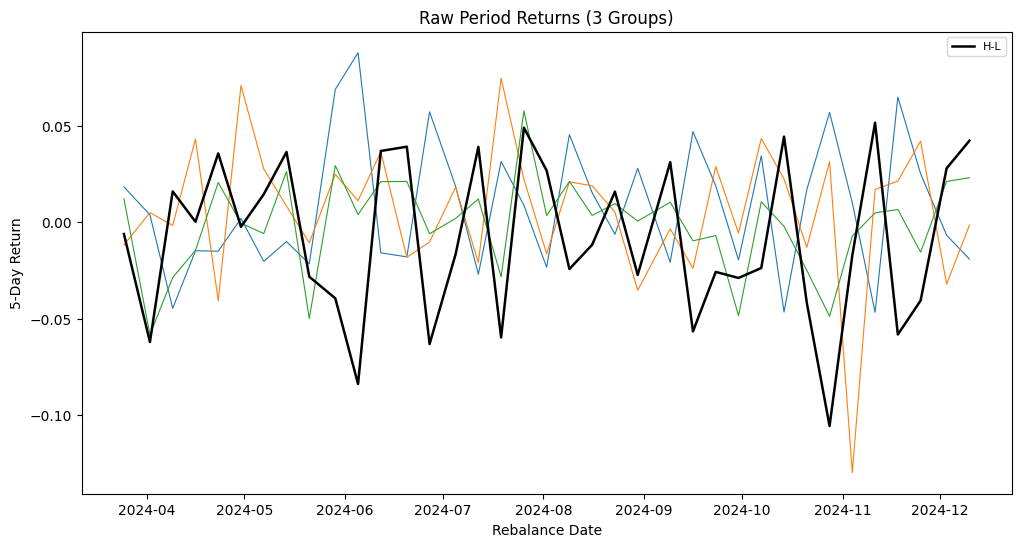

In [90]:
plt.figure(figsize=(12, 6))

for g in range(1, n_groups + 1):
    plt.plot(portfolio_wide.index, portfolio_wide[f"G{g}"], linewidth=0.8)

plt.plot(portfolio_wide.index, portfolio_wide["H-L"], linewidth=1.8, color="black", label="H-L")

plt.title(f"Raw Period Returns ({n_groups} Groups)")
plt.ylabel("5-Day Return")
plt.xlabel("Rebalance Date")
plt.legend(ncol=3, fontsize=8)
plt.show()